In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.distributions as TD
import torch.optim as optim
from torch.distributions import Normal, Bernoulli, Independent
import torchvision
from torchvision import transforms
from torchvision.utils import make_grid

from collections import defaultdict
from tqdm.notebook import tqdm
from typing import List, Union
import gc
import os
import numpy as np
from sklearn.datasets import make_regression
from sklearn.metrics import r2_score
from IPython.display import Image, display
from IPython.core.display import HTML
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline

import matplotlib.animation as animation
from torch.linalg import svd

In [10]:
clip = transforms.Lambda(lambda x: x.clip(-1.0, 1.0))
scale = transforms.Lambda(lambda x: x * 2 - 1)
unscale = transforms.Lambda(lambda x: (x + 1) / 2)

train_dataset = torchvision.datasets.CIFAR10(
        root='.', 
        train=True, 
        download=True,  
        transform=transforms.Compose([
            transforms.ToTensor(),
            scale,
            clip,
        ])
    )

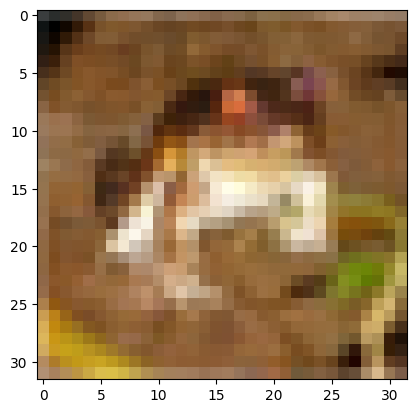

In [11]:
our_sample = train_dataset[0][0]

plt.imshow(unscale(our_sample.permute(1, 2, 0)))

In [12]:
len(train_dataset)

50000

In [13]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128, 
    shuffle=True
)

In [14]:
DEVICE = "cuda:0"

In [15]:
import torch
from diffusers import UNet2DModel
from diffusers.models.attention_processor import AttnProcessor2_0

model = UNet2DModel(
    # num_class_embeds=10,
    sample_size=32,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(128, 256, 256),
    down_block_types=("DownBlock2D", "DownBlock2D", "AttnDownBlock2D"),
    up_block_types=("AttnUpBlock2D", "UpBlock2D", "UpBlock2D"),
    attention_head_dim=4,
    norm_num_groups=32,
    mid_block_type="UNetMidBlock2D",
)

# Move to device first
model = model.to(DEVICE)

# 🔥 Manual method to enable FlashAttention-2 (works across diffusers versions)
def set_attn_processors(model, processor):
    """Recursively set attention processors for all attention modules in the model."""
    for name, module in model.named_modules():
        if hasattr(module, "set_processor"):
            module.set_processor(processor)
        # For older diffusers versions where attention modules have 'processor' attribute directly
        elif hasattr(module, "processor") and "Attention" in module.__class__.__name__:
            module.processor = processor

# Check if we can use AttnProcessor2_0 (PyTorch 2.0+ with efficient SDPA)
if hasattr(torch.nn.functional, "scaled_dot_product_attention"):
    processor = AttnProcessor2_0()
    print("✅ Using AttnProcessor2_0 (PyTorch 2.0 scaled_dot_product_attention)")
else:
    from diffusers.models.attention_processor import AttnProcessor
    processor = AttnProcessor()
    print("⚠️ PyTorch 2.0 not available. Using default attention processor.")

# Apply the processor to all attention modules
set_attn_processors(model, processor)

# Also ensure we're using bfloat16 if available and beneficial
if torch.cuda.is_bf16_supported():
    use_bf16 = True
    print("✅ bfloat16 is supported on this device")
else:
    use_bf16 = False
    print("⚠️ bfloat16 not supported, using float32")

/home/jovyan/.mlspace/envs/novitskiy-cu12.6-torch2.6.0-skoltech-v1/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-24 17:39:00.107319: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-24 17:39:00.116606: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774373940.125451 1374535 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:17743739

✅ Using AttnProcessor2_0 (PyTorch 2.0 scaled_dot_product_attention)
✅ bfloat16 is supported on this device


In [16]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.0)

In [17]:
sum([p.numel() for p in model.parameters()])

25838595

In [22]:
import torch

def svd_forward_process(image, t):
    # image: (H, W, 3) or (3, H, W) — we assume (H, W, 3) for this example
    # Adapt if your input is (C, H, W)
    if image.shape[-1] != 3:
        # assuming (C, H, W) → permute to (H, W, C)
        image = image.permute(1, 2, 0)  # now (H, W, 3)

    channels = []
    for c in range(3):  # R, G, B
        U, S, Vh = torch.linalg.svd(image[..., c], full_matrices=False)
        # Equivalent to your original logic
        U_slice = U[:, :t]
        V_slice = Vh.conj().T[:, :t]  # V = Vh.H → .conj().T for complex safety
        S_slice = S[:t]
        restored_channel = U_slice @ torch.diag(S_slice) @ V_slice.T
        channels.append(restored_channel)

    restored = torch.stack(channels, dim=-1)  # (H, W, 3)
    
    return restored

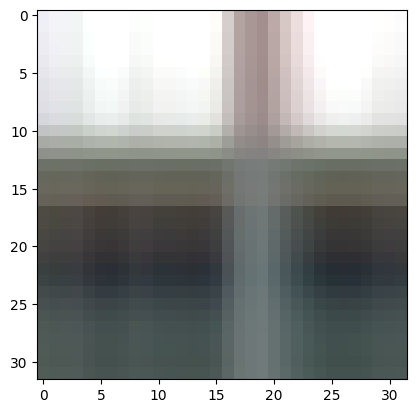

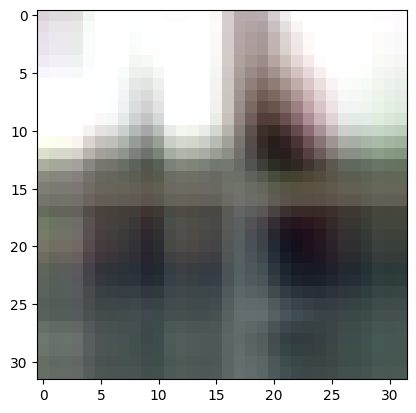

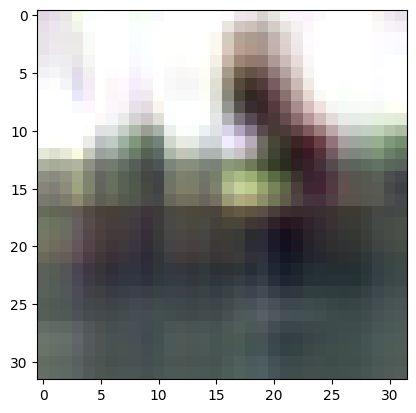

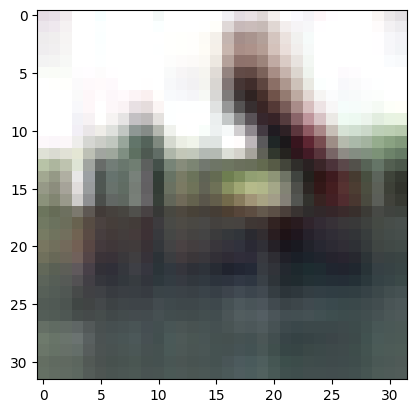

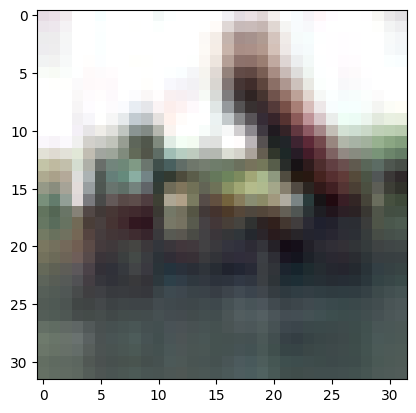

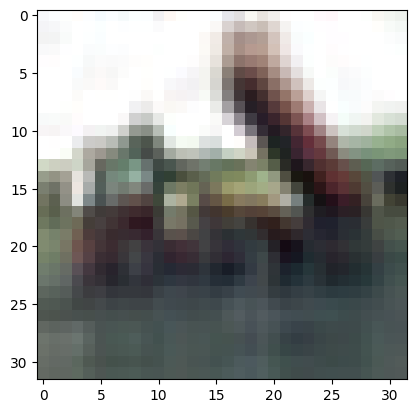

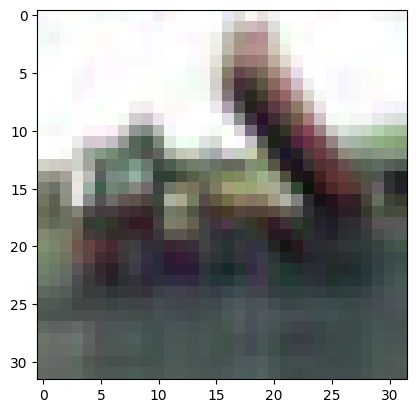

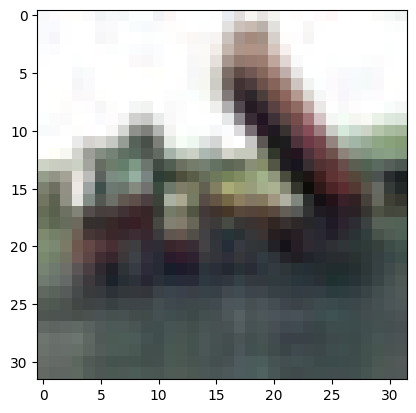

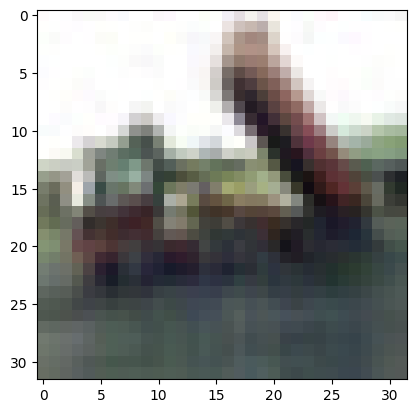

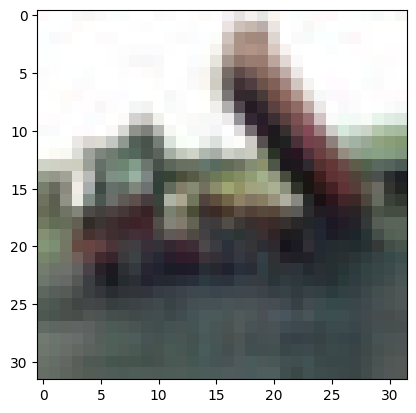

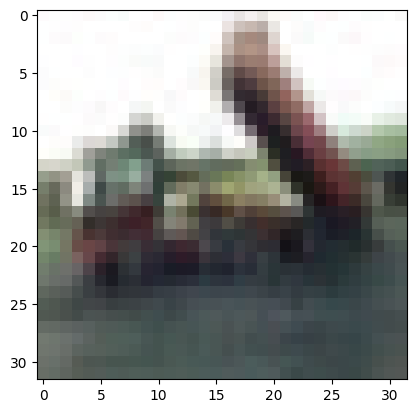

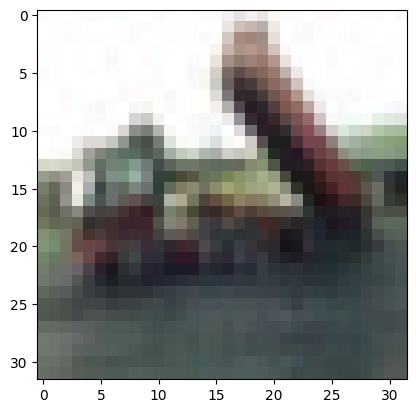

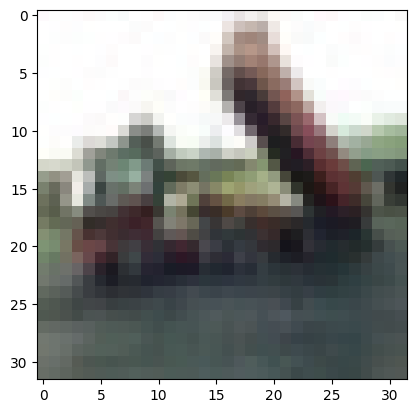

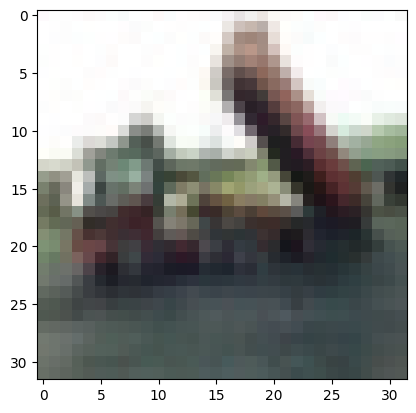

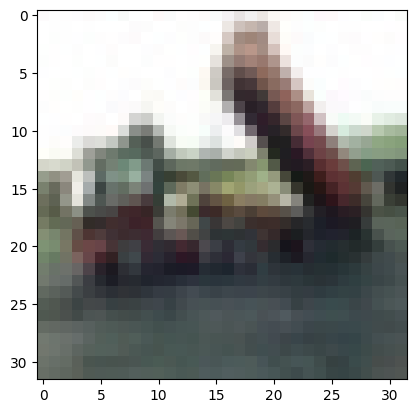

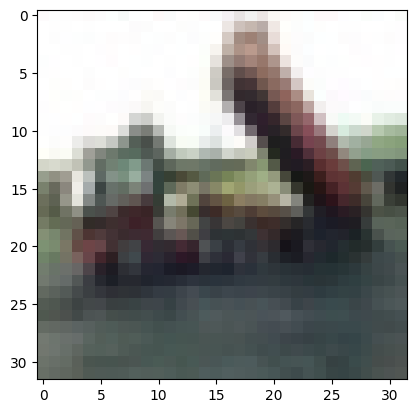

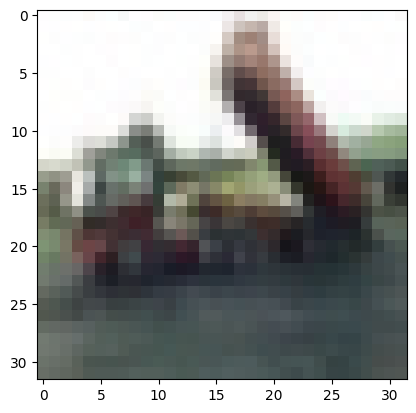

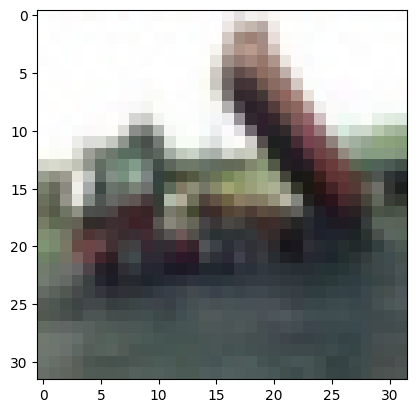

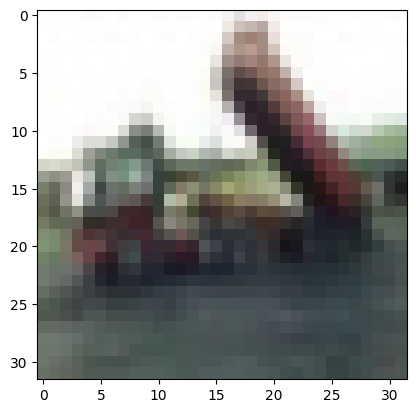

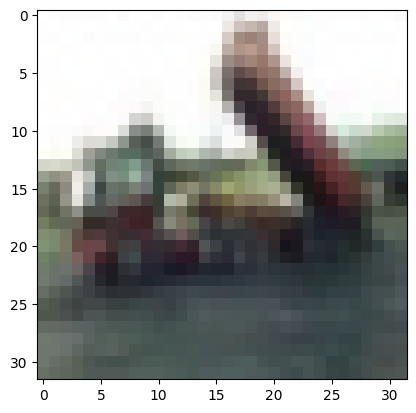

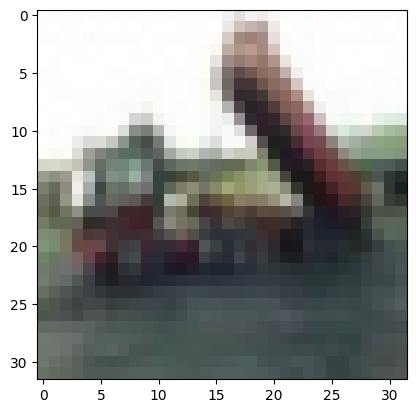

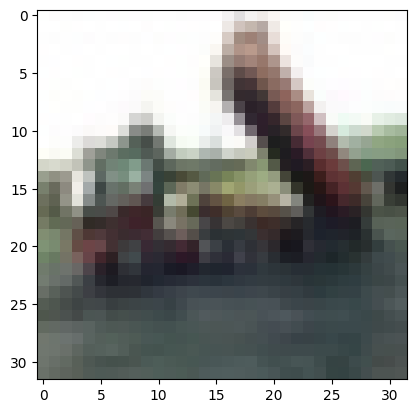

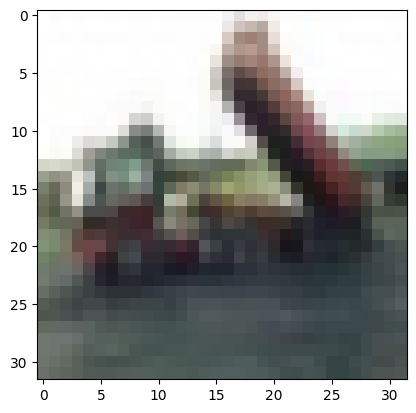

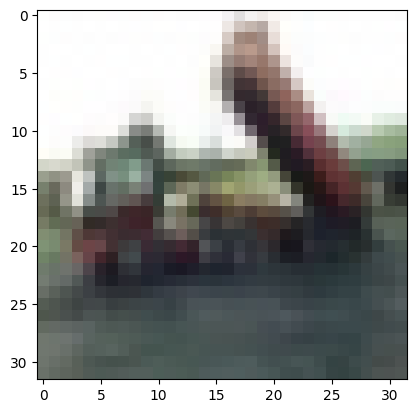

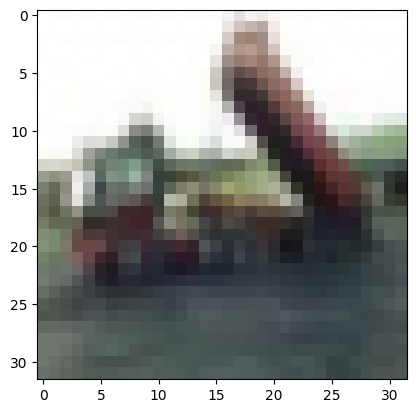

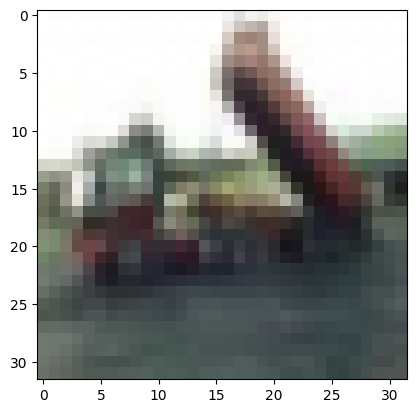

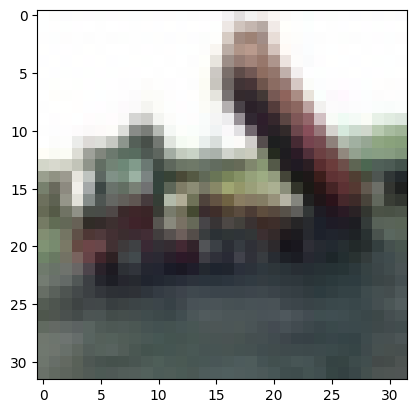

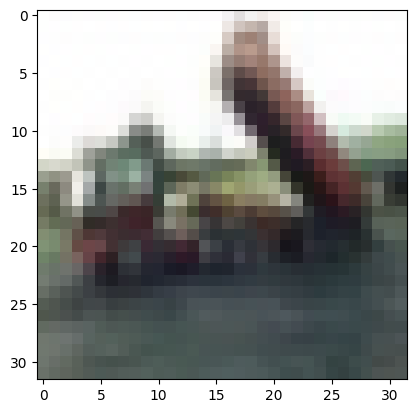

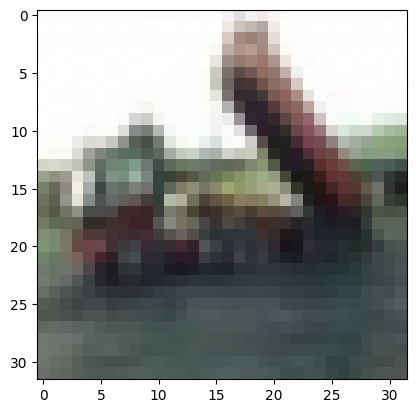

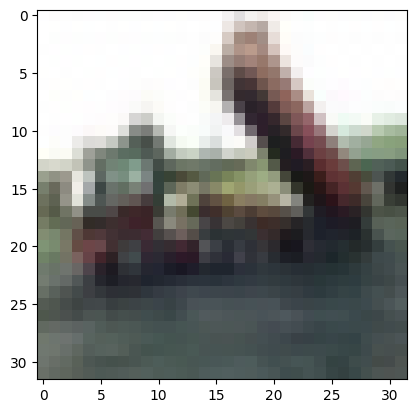

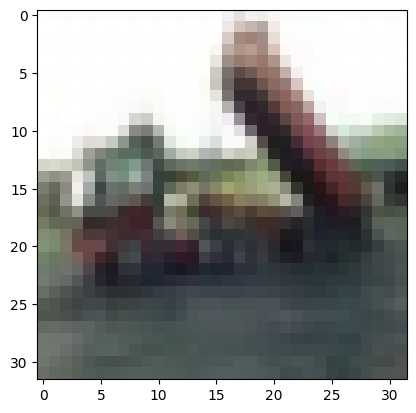

In [23]:
for n in range(1, 32):
    src = svd_forward_process(our_sample, n)
    plt.imshow(unscale(src))
    plt.show()

# Calculate Singular Values across Dataset

In [13]:
def get_scaled_singular_values(image):
    image = image.to(DEVICE)
    
    if image.shape[-1] != 3:
        image = image.permute(1, 2, 0)

    Ss = []
    for c in range(3):
        U, S, Vh = torch.linalg.svd(image[..., c], full_matrices=False)
        Ss.append(S.reshape(1, -1))

    S = torch.cat(Ss, dim=0).mean(dim=0)
    S = S / torch.sum(S.flatten())
    return S.cpu()

In [14]:
all_singular_weight = []

for i in tqdm(range(len(train_dataset))):
    all_singular_weight.append(get_scaled_singular_values(train_dataset[i][0]).unsqueeze(dim=0))

100%|██████████| 50000/50000 [00:54<00:00, 915.04it/s]


In [15]:
weights = torch.mean(torch.cat(all_singular_weight, dim=0), dim=0)
weights.shape

torch.Size([32])

In [16]:
weights

tensor([3.4004e-01, 1.5597e-01, 1.0034e-01, 7.1862e-02, 5.5320e-02, 4.4186e-02,
        3.6168e-02, 3.0058e-02, 2.5251e-02, 2.1400e-02, 1.8234e-02, 1.5603e-02,
        1.3383e-02, 1.1511e-02, 9.8989e-03, 8.5060e-03, 7.3053e-03, 6.2639e-03,
        5.3548e-03, 4.5593e-03, 3.8621e-03, 3.2499e-03, 2.7147e-03, 2.2447e-03,
        1.8322e-03, 1.4726e-03, 1.1566e-03, 8.7960e-04, 6.3730e-04, 4.2269e-04,
        2.3344e-04, 7.2670e-05])

<BarContainer object of 32 artists>

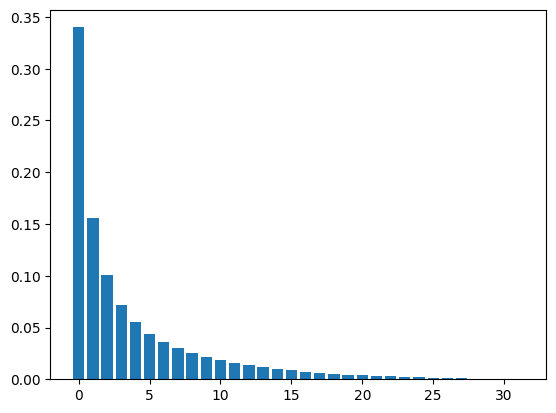

In [17]:
plt.bar([i for i in range(weights.shape[0])], weights.cpu().numpy())

In [18]:
torch.cuda.empty_cache()
gc.collect()

65

# Train

In [7]:
import os
os.listdir("/home/jovyan/novitskiy/Research/skoltech-nla2025-project/saves/cold_diff_cifar10_v1/")[-1]

'step_35189.pt'

In [ ]:
import torch
from torch.cuda.amp import autocast
from tqdm import tqdm

losses = []
CKPT_PATH = "/home/jovyan/novitskiy/Research/skoltech-nla2025-project/saves/cold_diff_cifar10_v1/"
log_every_n = 200
save_every_n = 10
num_epoches = 100
step = 0 
HIGH = 32

model.train()

for epoch in range(num_epoches):
    for images, labels in tqdm(train_loader):
        batch_src = []

        rec_step = torch.multinomial(weights, images.shape[0], replacement=True) + 1
                
        # Move images to device early (avoids repeated .to(DEVICE))
        images = images.to(DEVICE, non_blocking=True)
        for i in range(images.shape[0]):
            sample = images[i]
            src = svd_forward_process(sample, rec_step[i])  # assumes svd_forward_process handles device correctly
            batch_src.append(src.unsqueeze(0))

        src = torch.cat(batch_src, dim=0).permute(0, 3, 1, 2).to(DEVICE, non_blocking=True)
        target = images  # already on DEVICE
        rec_step = rec_step.to(DEVICE, non_blocking=True)
        labels = torch.tensor(labels, device=DEVICE, dtype=torch.long)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            output = model(sample=src, timestep=rec_step, return_dict=False)[0]
            loss = F.mse_loss(output, target)

        # Backward in full precision (PyTorch handles this automatically with autocast)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        if step % log_every_n == 0:
            print(f"Step {step}, Loss: {loss.item():.6f}")
            

        losses.append(loss.item())
        step += 1
        
    if (epoch + 1) % save_every_n == 0:
        torch.save(model.state_dict(), os.path.join(CKPT_PATH, f"step_{step}.pt"))
            

  0%|          | 0/391 [00:00<?, ?it/s]/tmp/ipykernel_1331157/1295213015.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels, device=DEVICE, dtype=torch.long)
  0%|          | 1/391 [00:00<01:22,  4.73it/s]

Step 0, Loss: 0.352622


 51%|█████▏    | 201/391 [00:41<00:41,  4.61it/s]

Step 200, Loss: 0.034327


  3%|▎         | 10/391 [00:02<01:17,  4.95it/s]

...

 60%|█████▉    | 234/391 [00:47<00:31,  4.96it/s]

Step 19000, Loss: 0.021469


 11%|█         | 42/391 [00:13<01:50,  3.16it/s]

Step 19200, Loss: 0.017987


 61%|██████▏   | 240/391 [01:14<00:46,  3.22it/s]

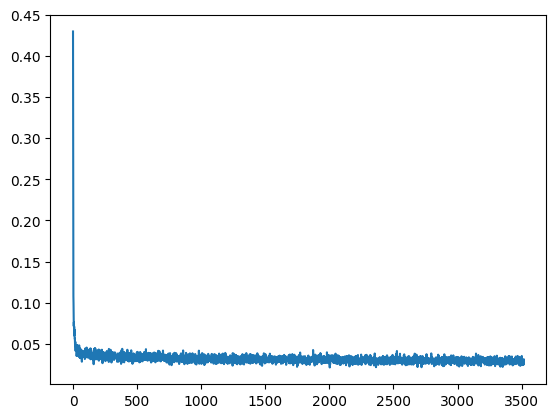

In [ ]:
plt.plot([i for i in range(len(losses))], losses)

# Generation

In [19]:
model.load_state_dict(torch.load("/home/jovyan/novitskiy/Research/skoltech-nla2025-project/saves/cold_diff_cifar10_v1/step_35000.pt"))

<All keys matched successfully>

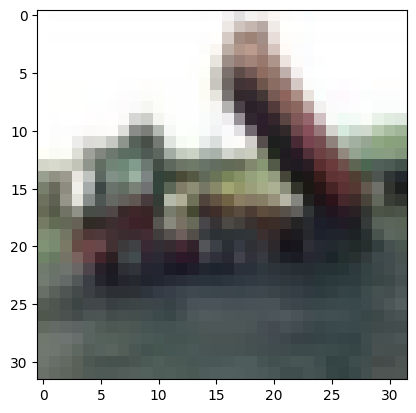

In [20]:
our_sample = train_dataset[2][0]


plt.imshow(unscale(our_sample.permute(1, 2, 0)))

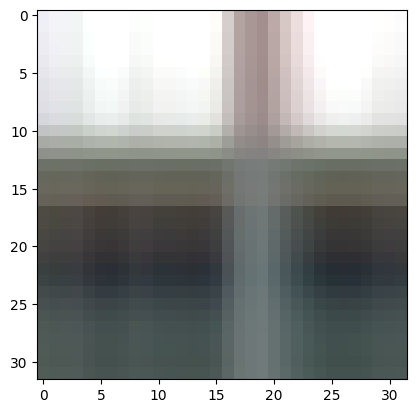

In [24]:
plt.imshow(unscale(svd_forward_process(our_sample, 1)))

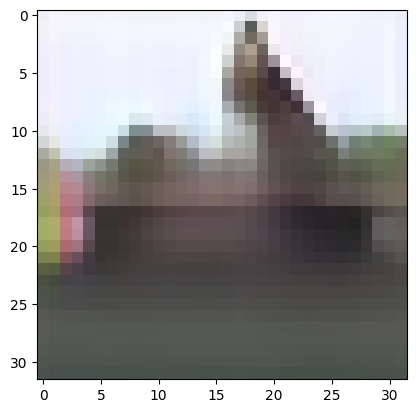

In [31]:
NFE = 14

imgs = []
fig = plt.figure()

x_t = svd_forward_process(our_sample, 1).permute(2, 0, 1)[None].to(DEVICE)

plot = plt.imshow(unscale(x_t[0].permute(1, 2, 0).cpu()))
imgs.append([plot])

model.eval()

for t in range(1, NFE):
    with torch.no_grad():
        x_0_approx = model(
            x_t.to(DEVICE), 
            torch.tensor(t).flatten().to(DEVICE),
            return_dict=False
        )[0]

        # print(x_0_approx.shape)
    
    x_t = svd_forward_process(x_0_approx[0].permute(1, 2, 0), t + 1).permute(2, 0, 1)[None]
     
    plot = plt.imshow(unscale(clip(x_t[0].permute(1, 2, 0).cpu())))
    imgs.append([plot])

ani = animation.ArtistAnimation(fig, imgs, interval=200, blit=True)
ani.save('svd_cold_scheme_1_generation.gif')

torch.Size([1, 3, 32, 32])


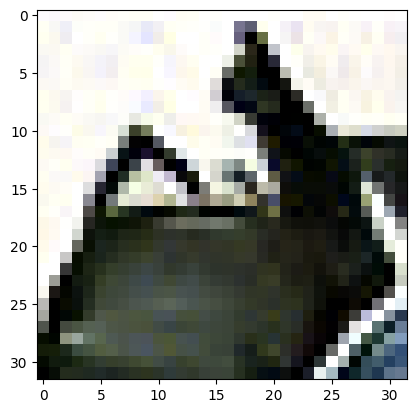

In [ ]:
NFE = 14

imgs = []
fig = plt.figure()

x_t = svd_forward_process(our_sample, 1).permute(2, 0, 1)[None].to(DEVICE)

print(x_t.shape)

plot = plt.imshow(unscale(x_t[0].permute(1, 2, 0).cpu()))
imgs.append([plot])

model.eval()

for t in range(1, NFE):
    with torch.no_grad():
        x_0_approx = model(
            x_t.to(DEVICE), 
            torch.tensor(t).flatten().to(DEVICE),
            return_dict=False
        )[0]
    
    x_t = x_0_approx - svd_forward_process(x_0_approx[0].permute(1, 2, 0), t).permute(2, 0, 1)[None] + svd_forward_process(x_0_approx[0].permute(1, 2, 0), t + 1).permute(2, 0, 1)[None]
        
    plot = plt.imshow(unscale(clip(x_t[0].permute(1, 2, 0).cpu())))
    imgs.append([plot])

ani = animation.ArtistAnimation(fig, imgs, interval=200, blit=True)
ani.save('svd_cold_scheme_2_generation.gif')

# Fit Prior

In [32]:
from sklearn.mixture import GaussianMixture
import numpy as np


def get_rank1_scaled(image):
    U, S, Vh = torch.linalg.svd(image, full_matrices=False)
    
    # Get rank-1 components
    u1 = U[:, 0]  # shape (28,)
    v1 = Vh[0, :]  # shape (28,) - Note: Vh[0] not V[:, 0]
    sigma1 = S[0]  # scalar
    
    # SCALE the vectors by √σ₁ to preserve reconstruction
    u_scaled = u1 * torch.sqrt(sigma1)
    v_scaled = v1 * torch.sqrt(sigma1)
    
    # Concatenate: [√σ*u, √σ*v, σ]
    # This preserves the outer product relationship
    return torch.cat([u_scaled, v_scaled, sigma1.unsqueeze(0)])

# Reconstruction from this format:
def reconstruct_from_scaled(vector):
    channels = []
    rgb_vectors = torch.chunk(vector, 3)

    for vector in rgb_vectors:
        u_scaled = vector[:32]
        v_scaled = vector[32:-1]
        sigma = vector[-1]
        
        # image = (√σ*u) ⊗ (√σ*v) = σ * (u ⊗ v)
        image = torch.outer(u_scaled, v_scaled)
        channels.append(image.unsqueeze(dim=0))

    return torch.cat(channels, dim=0)

In [ ]:
X = []

for i in tqdm(range(len(train_dataset))):
    chanelwise_rank1 = torch.cat([get_rank1_scaled(train_dataset[i][0][c]).flatten() for c in range(3)], dim=0).unsqueeze(0)
    X.append(chanelwise_rank1)
    
X = torch.cat(X)
X.shape

100%|██████████| 50000/50000 [01:52<00:00, 445.43it/s]


torch.Size([50000, 195])

: 

In [ ]:
n_components = 10
gmm = GaussianMixture(n_components=n_components, covariance_type='full', verbose=2, random_state=42)
gmm.fit(X.numpy())

Initialization 0


In [ ]:
sampled_vectors = gmm.sample(n_samples=100)[0]
sampled_vectors.shape

/home/jovyan/.mlspace/envs/novitskiy-cu12.6-torch2.6.0-skoltech-v1/lib/python3.10/site-packages/sklearn/mixture/_base.py:443: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  rng.multivariate_normal(mean, covariance, int(sample))


(100, 195)

torch.Size([32, 32])
torch.Size([32, 32])
torch.Size([32, 32])


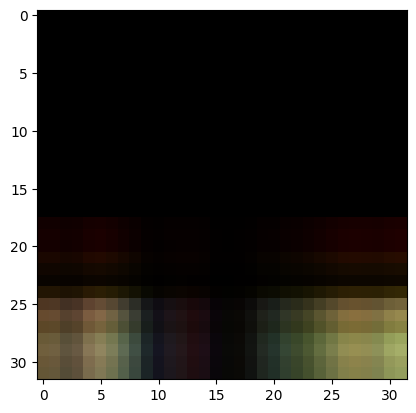

In [ ]:
src = reconstruct_from_scaled(torch.tensor(sampled_vectors[10])).float()
plt.imshow(src.permute(1, 2, 0))

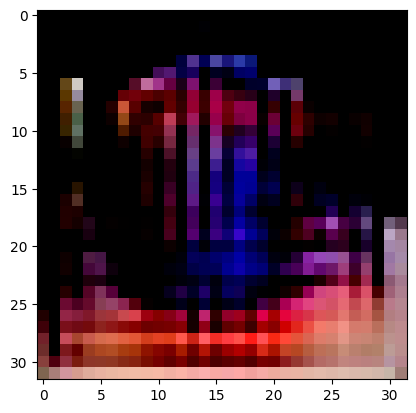

In [ ]:
NFE = 28

imgs = []
fig = plt.figure()

x_t = src[None].to(DEVICE)

plot = plt.imshow(x_t[0].cpu().permute(1, 2, 0))
imgs.append([plot])

model.eval()

for t in range(1, NFE):
    with torch.no_grad():
        x_0_approx = model(
            x_t.to(DEVICE), 
            torch.tensor(t).to(DEVICE),
            return_dict=False
        )[0]
    
    x_t = svd_forward_process(x_0_approx[0], t + 1)[None]
    plot = plt.imshow(x_t[0].cpu())
    imgs.append([plot])

    x_t = x_t.permute(0, 3, 1, 2)

ani = animation.ArtistAnimation(fig, imgs, interval=200, blit=True)
ani.save('svd_cold_scheme_1_generation.gif')

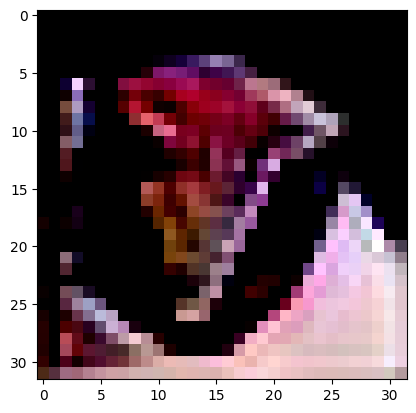

In [ ]:
NFE = 28

imgs = []
fig = plt.figure()

x_t = src[None].to(DEVICE)

plot = plt.imshow(x_t[0].cpu().permute(1, 2, 0))
imgs.append([plot])

model.eval()

for t in range(1, NFE):
    with torch.no_grad():
        x_0_approx = model(
            x_t.to(DEVICE), 
            torch.tensor(t).to(DEVICE),
            return_dict=False
        )[0]
    
    # x_t = svd_forward_process(x_0_approx[0], t + 1)[None]
    x_t = x_0_approx.permute(0, 2, 3, 1) - svd_forward_process(x_0_approx[0], t)[None] + svd_forward_process(x_0_approx[0], t + 1)[None]

    plot = plt.imshow(x_t[0].cpu())
    imgs.append([plot])

    x_t = x_t.permute(0, 3, 1, 2)

ani = animation.ArtistAnimation(fig, imgs, interval=200, blit=True)
ani.save('svd_cold_scheme_2_generation.gif')